In [17]:
# ============================================================
# Tugas 1: Clustering dataset pelanggan (sintetis)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Membuat dataset pelanggan sintetis (income dan spending)
X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

# Membuat dataframe
df = pd.DataFrame(X, columns=["Income", "Spending"])

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Evaluasi K
print("="*50)
print("EVALUASI K (2-10)")
print("="*50)

inertia = []
silhouette = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette.append(sil)

    print(f"K = {k} | Inertia = {kmeans.inertia_:.2f} | Silhouette = {sil:.3f}")

# Misal dipilih K terbaik
k_optimal = 4
print("\nK optimal yang digunakan:", k_optimal)

# Clustering akhir
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42)
df["Cluster"] = kmeans_final.fit_predict(X_scaled)

print("\n5 Data Pertama")
print(df.head())

EVALUASI K (2-10)
K = 2 | Inertia = 315.49 | Silhouette = 0.558
K = 3 | Inertia = 71.69 | Silhouette = 0.744
K = 4 | Inertia = 17.47 | Silhouette = 0.797
K = 5 | Inertia = 15.65 | Silhouette = 0.674
K = 6 | Inertia = 13.85 | Silhouette = 0.551
K = 7 | Inertia = 12.96 | Silhouette = 0.552
K = 8 | Inertia = 11.39 | Silhouette = 0.439
K = 9 | Inertia = 9.91 | Silhouette = 0.345
K = 10 | Inertia = 8.85 | Silhouette = 0.359

K optimal yang digunakan: 4

5 Data Pertama
      Income  Spending  Cluster
0  -9.297689  6.473679        3
1  -9.698741  6.938967        3
2  -1.686653  7.793442        0
3  -7.097308 -5.781333        1
4 -10.876452  6.315437        3


In [18]:
# =================================================
# SOAL 2 - Profil tiap cluster
# =================================================

print("\nProfil Cluster:")
print(f"{'Cluster':>8}  {'Avg Income':>12}  {'Avg Spending':>13}  {'Count':>6}")

for c in sorted(df["Cluster"].unique()):
    mask = df["Cluster"] == c
    avg_inc = df.loc[mask, "Income"].mean()
    avg_sp = df.loc[mask, "Spending"].mean()
    count = mask.sum()

    print(f"{c:>8d}  {avg_inc:>12.1f}  {avg_sp:>13.1f}  {count:>6d}")


Profil Cluster:
 Cluster    Avg Income   Avg Spending   Count
       0          -2.7            9.0      76
       1          -6.8           -6.8      75
       2           4.7            2.0      75
       3          -8.9            7.2      74



NAMA SEGMEN PELANGGAN
Data dengan Nama Segmen
      Income  Spending  Cluster             Segment
0  -9.297689  6.473679        3  Potential Customer
1  -9.698741  6.938967        3  Potential Customer
2  -1.686653  7.793442        0          High Value
3  -7.097308 -5.781333        1     Budget Customer
4 -10.876452  6.315437        3  Potential Customer


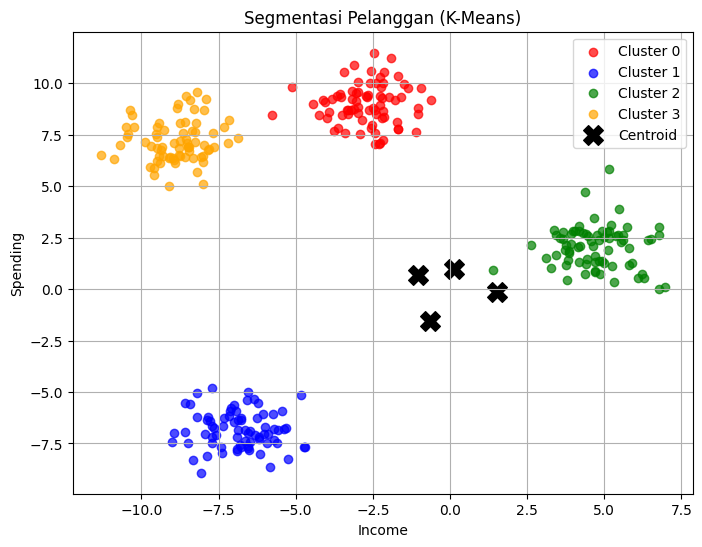

In [19]:
# =================================================
# SOAL 3 - Beri Nama Segmen
# =================================================

# Memberi nama segmen

print("\n" + "="*50)
print("NAMA SEGMEN PELANGGAN")
print("="*50)

segment_names = {
    0: "High Value",
    1: "Budget Customer",
    2: "Regular Customer",
    3: "Potential Customer"
}

df["Segment"] = df["Cluster"].map(segment_names)

print("Data dengan Nama Segmen")
print(df.head())

# =================================================
# Visualisasi Cluster yang Lebih Baik
# =================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

colors = ["red", "blue", "green", "orange"]

for c in sorted(df["Cluster"].unique()):
    mask = df["Cluster"] == c
    plt.scatter(df.loc[mask, "Income"],
                df.loc[mask, "Spending"],
                color=colors[c],
                label=f"Cluster {c}",
                alpha=0.7)

# Menampilkan centroid
centroids = kmeans_final.cluster_centers_

plt.scatter(centroids[:,0],
            centroids[:,1],
            color="black",
            marker="X",
            s=200,
            label="Centroid")

plt.xlabel("Income")
plt.ylabel("Spending")
plt.title("Segmentasi Pelanggan (K-Means)")
plt.legend()
plt.grid(True)

plt.show()

In [20]:
# =================================================
# SOAL 4 - 3 Rekomendasi Bisnis
# =================================================

print("\n=== 3 Rekomendasi Bisnis ===")

print("1. Segmen 'Premium' (income & spending tinggi): berikan loyalty program")
print("   dan produk eksklusif untuk mempertahankan pengeluaran mereka.")

print("2. Segmen 'Saver' (income tinggi, spending rendah): buat promo menarik")
print("   untuk mendorong mereka belanja lebih banyak.")

print("3. Segmen 'Budget' (income & spending rendah): tawarkan produk terjangkau")
print("   dan diskon agar tetap menjadi pelanggan setia.")


=== 3 Rekomendasi Bisnis ===
1. Segmen 'Premium' (income & spending tinggi): berikan loyalty program
   dan produk eksklusif untuk mempertahankan pengeluaran mereka.
2. Segmen 'Saver' (income tinggi, spending rendah): buat promo menarik
   untuk mendorong mereka belanja lebih banyak.
3. Segmen 'Budget' (income & spending rendah): tawarkan produk terjangkau
   dan diskon agar tetap menjadi pelanggan setia.
